Predicted Speed: 68.33


C:\Users\shari\anaconda3\Lib\site-packages\skfuzzy\control\fuzzyvariable.py:125: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


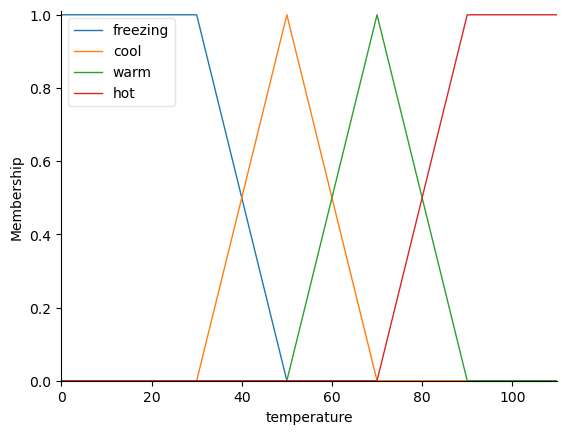

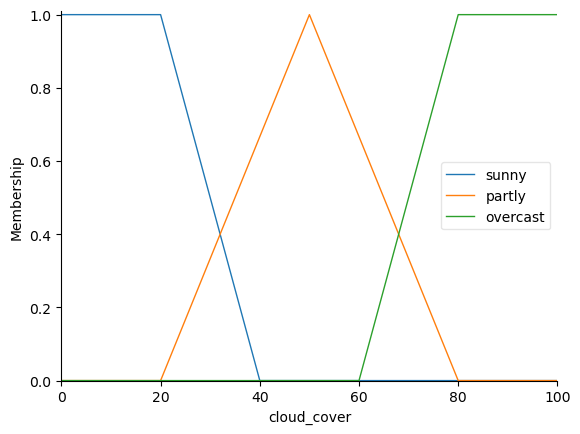

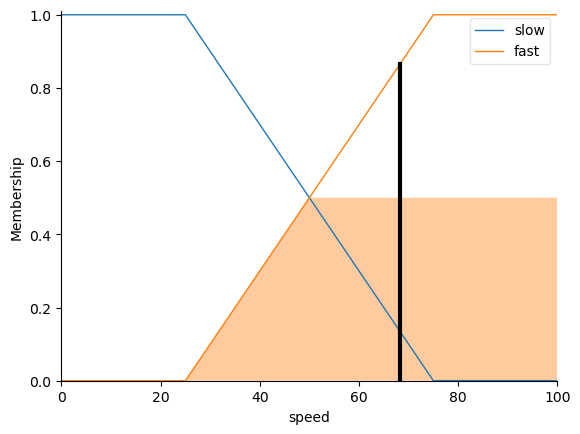

In [1]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt

temp = ctrl.Antecedent(np.arange(0, 111, 1), 'temperature')
cloud = ctrl.Antecedent(np.arange(0, 101, 1), 'cloud_cover')
speed = ctrl.Consequent(np.arange(0, 101, 1), 'speed')

temp['freezing'] = fuzz.trapmf(temp.universe, [0, 0, 30, 50])
temp['cool'] = fuzz.trimf(temp.universe, [30, 50, 70])
temp['warm'] = fuzz.trimf(temp.universe, [50, 70, 90])
temp['hot'] = fuzz.trapmf(temp.universe, [70, 90, 110, 110])

cloud['sunny'] = fuzz.trapmf(cloud.universe, [0, 0, 20, 40])
cloud['partly'] = fuzz.trimf(cloud.universe, [20, 50, 80])
cloud['overcast'] = fuzz.trapmf(cloud.universe, [60, 80, 100, 100])

speed['slow'] = fuzz.trapmf(speed.universe, [0, 0, 25, 75])
speed['fast'] = fuzz.trapmf(speed.universe, [25, 75, 100, 100])

rule1 = ctrl.Rule(cloud['sunny'] & temp['warm'], speed['fast'])
rule2 = ctrl.Rule(cloud['overcast'] & temp['cool'], speed['slow'])

system = ctrl.ControlSystem([rule1, rule2])
sim = ctrl.ControlSystemSimulation(system)

sim.input['temperature'] = 65 
sim.input['cloud_cover'] = 30 

sim.compute()
print("Predicted Speed:", round(sim.output['speed'], 2))

temp.view()
cloud.view()
speed.view(sim=sim)
plt.show()